#HW 2: Merge Sort

- Please disable code autocomplete by uncheck "Show context-powered code completions" in Tools -> Settings -> Editor.

##Implement Merge Sort

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [27]:
import math


# Implement Merge Sort
# Refer to Merge Sort described in Chapter 1.4 in Textbook

def MergeSort(array):
    if len(array) == 1:
        return array

    mid_point = math.ceil(len(array) / 2)
    left, right = MergeSort(array[:mid_point]), MergeSort(array[mid_point:])

    if left[-1] <= right[0]:
        return np.concatenate((left, right))

    i = j = 0
    arr = []
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            arr.append(left[i])
            i += 1
        else:
            arr.append(right[j])
            j += 1

    arr.extend(left[i:])
    arr.extend(right[j:])

    return arr


In [7]:
# Help function for testing

def IsSorted(array):
    for i in range(len(array)-1):
        if array[i] > array[i+1]:
            return False

    return True


In [24]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1]]

for testCase in testCases:
    print(testCase)
    output = MergeSort(testCase)
    print(output)
    print(IsSorted(output))

[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True


##Plot the run-time complexity

In [28]:
maxNumber = 20000
startArraySize = 100
endArraySize = 1000
stepArraySize = 100
runsPerSize = 1000

# Generate a random array of a given size
def GenerateRandomArray(size):
    return np.random.randint(0, maxNumber, size)

# Get run-time experiments for random arrays of different sizes for an algorithm
def RunExperiments(algorithm):
    averageRunTimes = []
    worstRunTimes = []

    np.random.seed(42)

    for arraySize in range(startArraySize, endArraySize+1, stepArraySize):
        runTimes = []
        for run in range(runsPerSize):
            array = GenerateRandomArray(arraySize)
            start = time.time()
            output = algorithm(array)
            end = time.time()
            runTimes.append(end-start)

            if IsSorted(output) == False:
                print("Array is not sorted")
                print("Orginal array: " + str(array))
                print("Sorted array: " + str(output))

        averageRunTimes.append(np.mean(runTimes))
        worstRunTimes.append(np.max(runTimes))

    return averageRunTimes, worstRunTimes



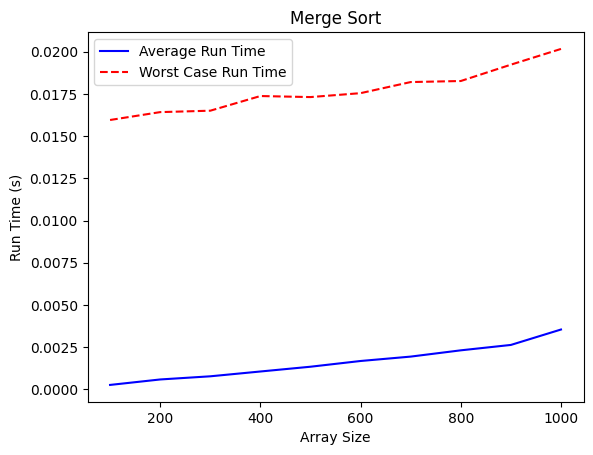

In [29]:
# Plot the experimental results for merge sort
averageRunTimesMergeSort, worstRunTimesMergeSort = RunExperiments(MergeSort)

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesMergeSort, 'b', label='Average Run Time')
plt.plot(x, worstRunTimesMergeSort, 'r--', label='Worst Case Run Time')
plt.title('Merge Sort')
plt.xlabel('Array Size')
plt.ylabel('Run Time (s)')
plt.legend()
plt.show()

##Compare to Insertion Sort

In [31]:
# Implement Insertion Sort

def InsertionSort(array):
    for i in range(1, len(array)):
        curr = array[i]
        j = i - 1
        while j >= 0 and array[j] > curr:
            array[j + 1] = array[j]
            j -= 1

        array[j + 1] = curr

    return array


In [32]:
# Quick test on some input arrays
testCases = [[1, 2, 3, 4, 5],
             [2, 1, 4, 3, 5],
             [3, 2, 1, 5, 4],
             [5, 4, 3, 2, 1]]

for testCase in testCases:
    print(testCase)
    output = InsertionSort(testCase)
    print(output)
    print(IsSorted(output))

[1, 2, 3, 4, 5]
[1, 2, 3, 4, 5]
True
[2, 1, 4, 3, 5]
[1, 2, 3, 4, 5]
True
[3, 2, 1, 5, 4]
[1, 2, 3, 4, 5]
True
[5, 4, 3, 2, 1]
[1, 2, 3, 4, 5]
True


In [ ]:
# Plot the experimental results for both insertion sort and merge sort
averageRunTimesInsertionSort, worstRunTimesInsertionSort = RunExperiments(InsertionSort)

x = np.arange(startArraySize, endArraySize+1, stepArraySize)
plt.plot(x, averageRunTimesMergeSort, 'b', label='Merge Sort')
plt.plot(x, averageRunTimesInsertionSort, 'r--', label='Insertion Sort')
plt.title('Compare Merge Sort with Insertion Sort')
plt.xlabel('Array Size')
plt.ylabel('Average Run Time (s)')
plt.legend()
plt.show()